# **KUIS PEMBELAJARAN MESIN**

**Nama**  : Mufliha Hafsyah Shahieza <br>
**NIM**   : 244107020147 <br>
**Kelas** : TI-3G

---

# **Komparasi Kmeans Euclidean vs Kmeans Manhattan vs Kmeans Cosine**


In [1]:
import os, time, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    pairwise_distances, adjusted_rand_score, normalized_mutual_info_score
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeansComparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
K = 4   # jumlah klaster, dari elbow method di notebook Euclidean
np.random.seed(RANDOM_STATE)

print(f"[INFO] Siap. k = {K} | random state = {RANDOM_STATE} | output: '{OUTPUT_DIR}'")

Mounted at /content/drive
[INFO] Siap. k = 4 | random state = 42 | output: 'outputKmeansComparison'


In [2]:
# --- Load ---
DATASET_PATH = '/content/drive/MyDrive/ML2026/diabetes_012_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATASET_PATH)
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

# --- Preprocessing ---
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")

# Buang kolom Income
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Hapus duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

df = df.reset_index(drop=True)

# Pisahkan label dan fitur
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur: {df_features.shape[1]}")

# Standardisasi (untuk Euclidean & Manhattan)
X_std = StandardScaler().fit_transform(df_features.values)

# L2 Normalisasi di atas data terstandarisasi (untuk Cosine)
X_norm = Normalizer(norm='l2').fit_transform(X_std)

print(f"\nX_std  : {X_std.shape}")
print(f"X_norm : {X_norm.shape}")
print("Harus (208858, 20). Kalau beda, cek lagi preprocessing.")

Data awal: 253680 baris x 22 kolom
Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur: 20

X_std  : (208858, 20)
X_norm : (208858, 20)
Harus (208858, 20). Kalau beda, cek lagi preprocessing.


In [3]:
class CustomKMeans:
    """
    K-Means multi-metrik:
    - euclidean : centroid = mean
    - manhattan : centroid = median (K-Medians)
    - cosine    : centroid = mean lalu dinormalisasi L2 (Spherical K-Means)
    """
    def __init__(self, n_clusters=3, metric='euclidean', max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric.lower()
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric=self.metric)

    def _init_centroids(self, X):
        # Inisialisasi gaya K-Means++
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]
        centroids = [X[rng.randint(n_samples)]]

        for _ in range(1, self.n_clusters):
            dists = self._compute_distance(X, np.array(centroids))
            sq = np.min(dists, axis=1) ** 2
            total = sq.sum()
            probs = np.ones(n_samples) / n_samples if total == 0 else sq / total
            centroids.append(X[rng.choice(n_samples, p=probs)])

        centroids = np.array(centroids)
        if self.metric == 'cosine':
            norms = np.linalg.norm(centroids, axis=1, keepdims=True)
            norms[norms == 0] = 1e-10
            centroids = centroids / norms
        return centroids

    def _update_centroids(self, X, labels):
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        rng = np.random.RandomState(self.random_state)
        for k in range(self.n_clusters):
            pts = X[labels == k]
            if len(pts) == 0:
                centroids[k] = X[rng.randint(len(X))]
            elif self.metric == 'euclidean':
                centroids[k] = np.mean(pts, axis=0)
            elif self.metric == 'manhattan':
                centroids[k] = np.median(pts, axis=0)
            elif self.metric == 'cosine':
                mean_vec = np.mean(pts, axis=0)
                norm = np.linalg.norm(mean_vec)
                centroids[k] = mean_vec / (norm if norm > 0 else 1.0)
        return centroids

    def fit(self, X):
        start = time.perf_counter()

        if self.metric == 'cosine':
            norms = np.linalg.norm(X, axis=1, keepdims=True)
            norms[norms == 0] = 1e-10
            X_calc = X / norms
        else:
            X_calc = X

        self.centroids = self._init_centroids(X_calc)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)
            new_centroids = self._update_centroids(X_calc, labels)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels
            if shift < self.tol:
                break

        final = self._compute_distance(X_calc, self.centroids)
        assigned = final[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned ** 2))
        self.execution_time_ = float(time.perf_counter() - start)
        return self

print("[INFO] Kelas CustomKMeans siap.")

[INFO] Kelas CustomKMeans siap.


In [4]:
configs = {
    'Euclidean': ('euclidean', X_std),
    'Manhattan': ('manhattan', X_std),
    'Cosine'   : ('cosine',    X_norm),
}

models, rows = {}, []

for name, (metric, data) in configs.items():
    print(f"[TRAINING] K-Means {name} (k={K}) ...")
    m = CustomKMeans(n_clusters=K, metric=metric, random_state=RANDOM_STATE).fit(data)
    models[name] = m

    sil = silhouette_score(data, m.labels_, metric=metric,
                           sample_size=10000, random_state=RANDOM_STATE)
    sizes = np.bincount(m.labels_, minlength=K)

    rows.append({
        'Distance Metric'            : name,
        'Silhouette Score (↑)'       : round(sil, 4),
        'Davies–Bouldin Index (↓)'   : round(davies_bouldin_score(data, m.labels_), 4),
        'Calinski–Harabasz Index (↑)': round(calinski_harabasz_score(data, m.labels_), 2),
        'Execution Time (s) (↓)'     : round(m.execution_time_, 3),
        'Iterations'                 : m.n_iter_,
        'Objective Value (J)'        : round(m.inertia_, 2),
        'ARI vs Diabetes (↑)'        : round(adjusted_rand_score(y_label, m.labels_), 4),
        'NMI vs Diabetes (↑)'        : round(normalized_mutual_info_score(y_label, m.labels_), 4),
        'Ukuran Klaster (min–max)'   : f"{sizes.min():,} – {sizes.max():,}",
    })

df_comparison = pd.DataFrame(rows)

print("\n" + "=" * 100)
print(f"TABEL KOMPARASI K-MEANS: EUCLIDEAN vs MANHATTAN vs COSINE (k = {K})")
print("=" * 100)
display(df_comparison)
print("Catatan: Objective Value (J) tidak dapat dibandingkan antar metrik (skala berbeda).")

df_comparison.to_csv(os.path.join(OUTPUT_DIR, "metrics_comparison_kmeans.csv"), index=False)

[TRAINING] K-Means Euclidean (k=4) ...
[TRAINING] K-Means Manhattan (k=4) ...
[TRAINING] K-Means Cosine (k=4) ...

TABEL KOMPARASI K-MEANS: EUCLIDEAN vs MANHATTAN vs COSINE (k = 4)


,Distance Metric,Silhouette Score (↑),Davies–Bouldin Index (↓),Calinski–Harabasz Index (↑),Execution Time (s) (↓),Iterations,Objective Value (J),ARI vs Diabetes (↑),NMI vs Diabetes (↑),Ukuran Klaster (min–max)
0,Euclidean,0.0811,2.6378,17124.85,6.269,43,3352501.30,0.0631,0.0589,"11,827 – 87,571"
1,Manhattan,0.1299,2.9811,12961.67,0.929,4,21663057.87,0.0692,0.0486,"12,000 – 98,975"
2,Cosine,0.1642,2.8177,15784.16,2.339,21,73183.98,0.0197,0.0368,"34,836 – 64,236"


Catatan: Objective Value (J) tidak dapat dibandingkan antar metrik (skala berbeda).


In [5]:
d = df_comparison.set_index('Distance Metric')

ringkasan = pd.DataFrame({
    'Kriteria': ['Silhouette tertinggi', 'Davies–Bouldin terendah',
                 'Calinski–Harabasz tertinggi', 'Waktu tercepat',
                 'Iterasi tersedikit', 'ARI vs Diabetes tertinggi', 'NMI vs Diabetes tertinggi'],
    'Pemenang': [
        d['Silhouette Score (↑)'].idxmax(),
        d['Davies–Bouldin Index (↓)'].idxmin(),
        d['Calinski–Harabasz Index (↑)'].idxmax(),
        d['Execution Time (s) (↓)'].idxmin(),
        d['Iterations'].idxmin(),
        d['ARI vs Diabetes (↑)'].idxmax(),
        d['NMI vs Diabetes (↑)'].idxmax(),
    ]
})
display(ringkasan)
ringkasan.to_csv(os.path.join(OUTPUT_DIR, "ringkasan_pemenang.csv"), index=False)

,Kriteria,Pemenang
0,Silhouette tertinggi,Cosine
1,Davies–Bouldin terendah,Euclidean
2,Calinski–Harabasz tertinggi,Euclidean
3,Waktu tercepat,Manhattan
4,Iterasi tersedikit,Manhattan
5,ARI vs Diabetes tertinggi,Manhattan
6,NMI vs Diabetes tertinggi,Euclidean


In [6]:
df_prof = pd.DataFrame({'Diabetes_012': y_label.values})
for name, m in models.items():
    df_prof[name] = m.labels_

hasil_profil = []
for name in models:
    t = df_prof.groupby(name)['Diabetes_012'].agg(
        Jumlah='count',
        Pct_Diabetes=lambda s: round((s == 2).mean() * 100, 2)
    ).reset_index().rename(columns={name: 'Klaster'})
    t.insert(0, 'Metrik', name)
    hasil_profil.append(t)

df_profil = pd.concat(hasil_profil, ignore_index=True)
display(df_profil)
df_profil.to_csv(os.path.join(OUTPUT_DIR, "profil_klaster_diabetes.csv"), index=False)

,Metrik,Klaster,Jumlah,Pct_Diabetes
0,Euclidean,0,73958,22.76
1,Euclidean,1,35502,34.38
2,Euclidean,2,11827,11.09
3,Euclidean,3,87571,4.86
4,Manhattan,0,98975,7.55
5,Manhattan,1,12000,6.78
6,Manhattan,2,32579,35.43
7,Manhattan,3,65304,22.63
8,Cosine,0,64236,7.72
9,Cosine,1,53548,12.38


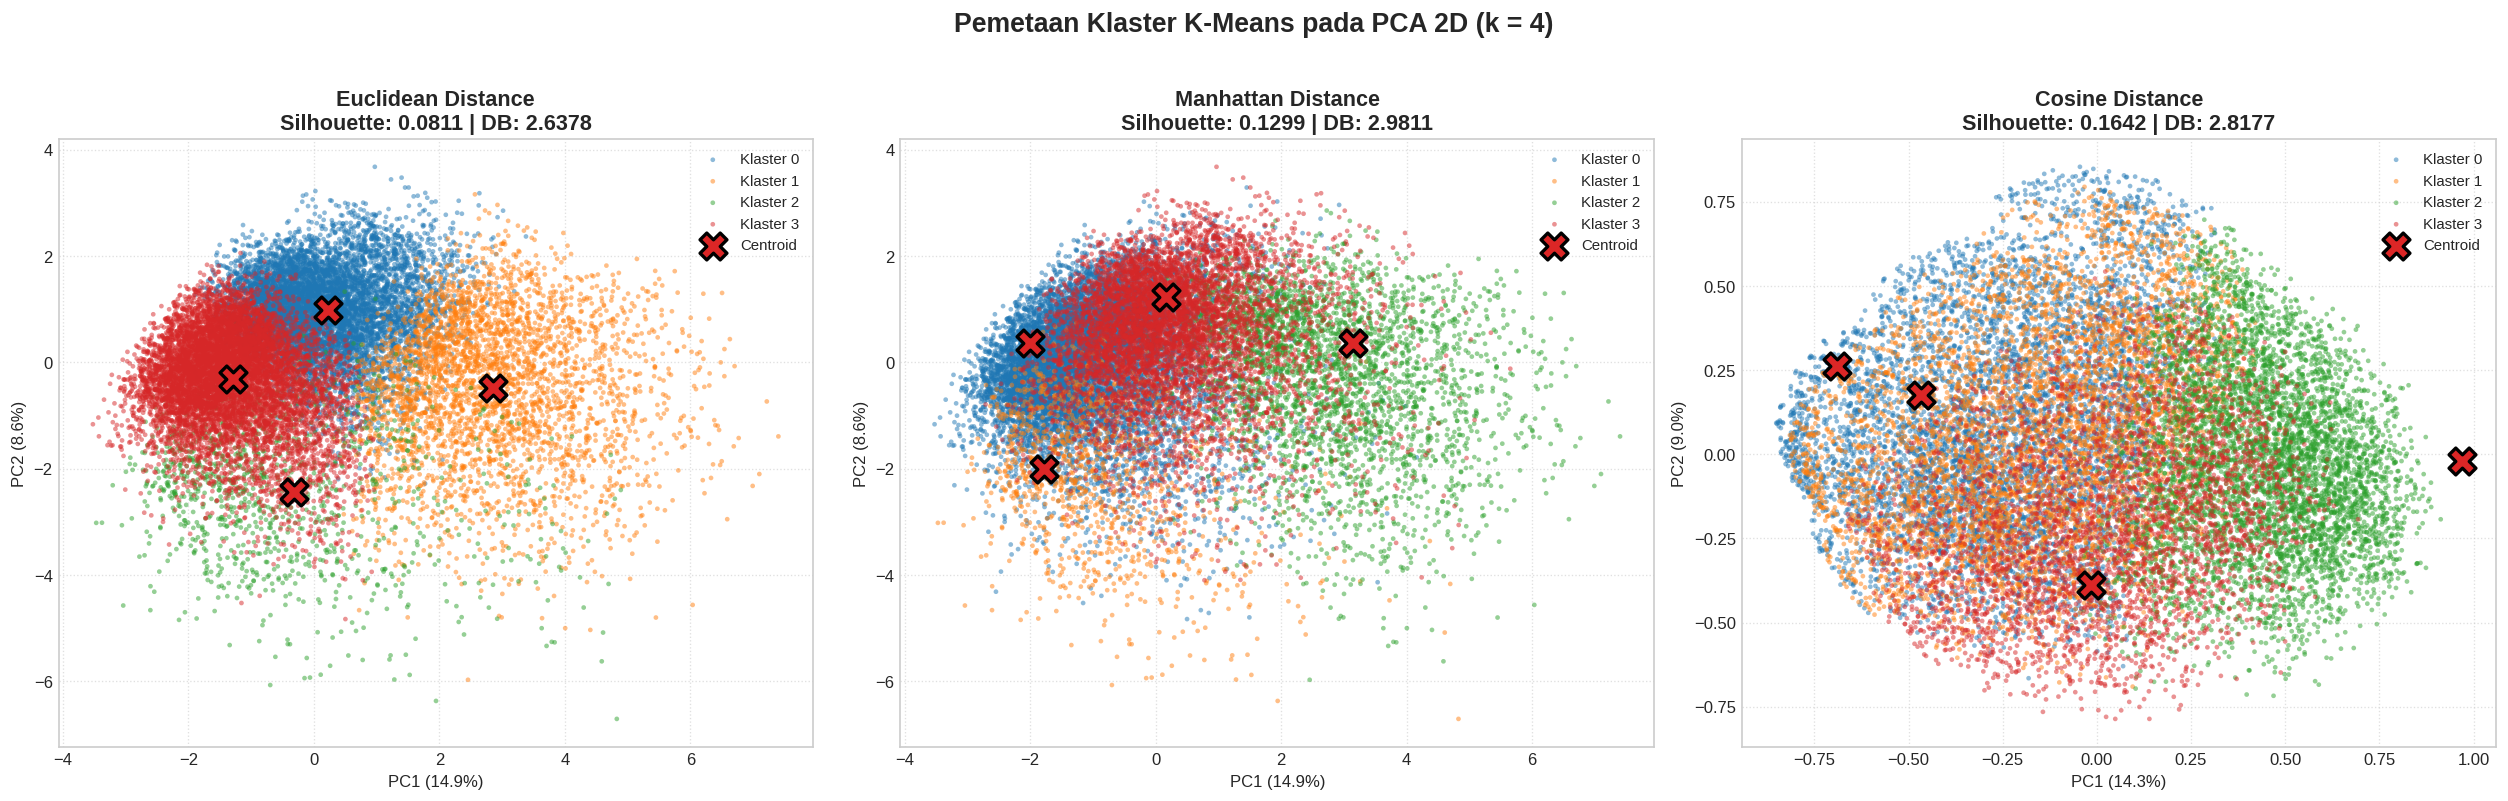

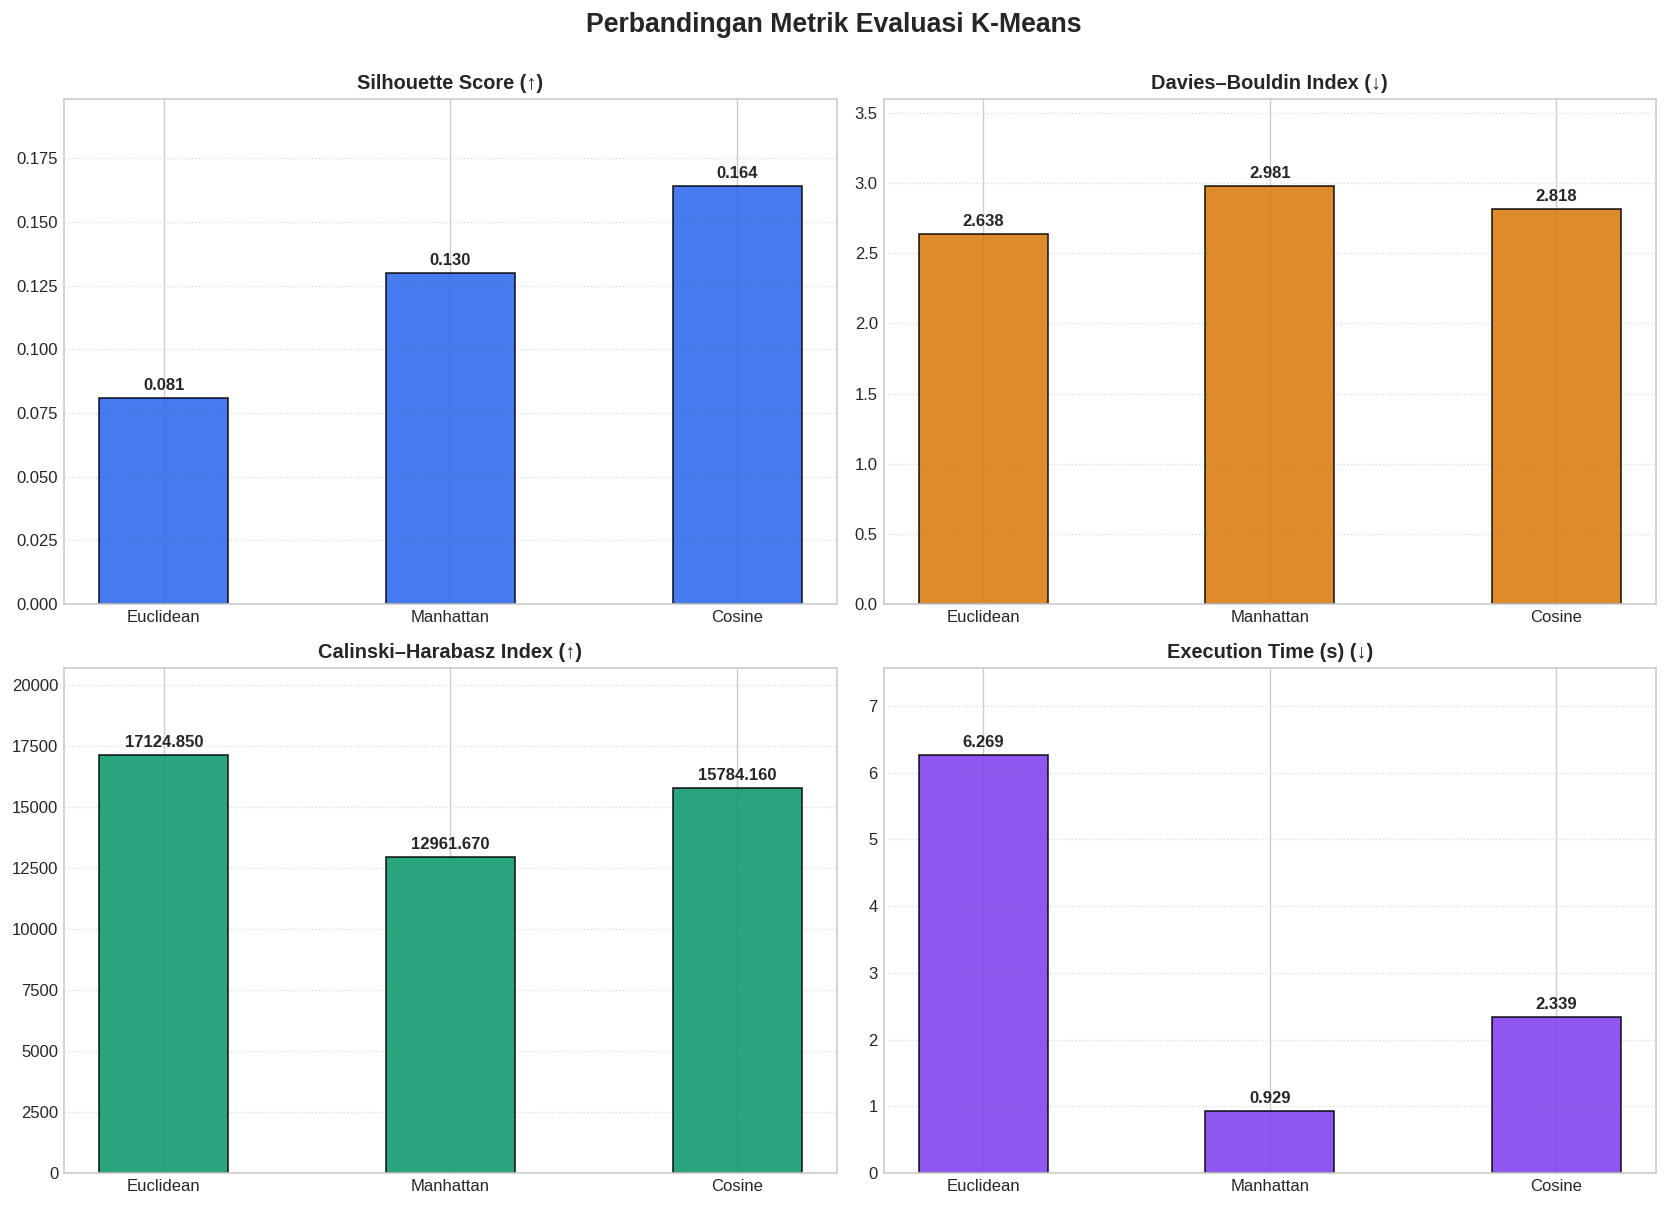

In [7]:
# --- PCA 2D ---
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_std), size=20000, replace=False)   # sampel untuk plot

pca_std  = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_std)
pca_norm = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_norm)
views = {
    'Euclidean': (X_std,  pca_std),
    'Manhattan': (X_std,  pca_std),
    'Cosine'   : (X_norm, pca_norm),
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
pal = sns.color_palette("tab10", K)

for ax, (name, (data, pca)) in zip(axes, views.items()):
    X2  = pca.transform(data[idx])
    lab = models[name].labels_[idx]
    for k in range(K):
        mask = lab == k
        ax.scatter(X2[mask, 0], X2[mask, 1], s=8, alpha=0.5, color=pal[k],
                   label=f'Klaster {k}', edgecolors='none')
    c2 = pca.transform(models[name].centroids)
    ax.scatter(c2[:, 0], c2[:, 1], marker='X', s=260, c='#DC2626',
               edgecolor='black', linewidth=2, label='Centroid', zorder=10)

    r = df_comparison[df_comparison['Distance Metric'] == name].iloc[0]
    ax.set_title(f"{name} Distance\nSilhouette: {r['Silhouette Score (↑)']} | DB: {r['Davies–Bouldin Index (↓)']}",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle(f'Pemetaan Klaster K-Means pada PCA 2D (k = {K})', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_comparison_pca2d.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- Bar chart metrik ---
cols = ['Silhouette Score (↑)', 'Davies–Bouldin Index (↓)',
        'Calinski–Harabasz Index (↑)', 'Execution Time (s) (↓)']
colors = ['#2563EB', '#D97706', '#059669', '#7C3AED']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, c, col in zip(axes.ravel(), cols, colors):
    bars = ax.bar(df_comparison['Distance Metric'], df_comparison[c],
                  width=0.45, color=col, edgecolor='black', alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontweight='bold')
    ax.set_title(c, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.suptitle('Perbandingan Metrik Evaluasi K-Means', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "metrics_comparison_barchart.png"), dpi=300, bbox_inches='tight')
plt.show()

In [8]:
tujuan = "/content/drive/MyDrive/ml-sem5/kuis1/outputKmeansComparison"
shutil.copytree(f"/content/{OUTPUT_DIR}", tujuan, dirs_exist_ok=True)
print(os.listdir(tujuan))

['cluster_comparison_pca2d.png', 'ringkasan_pemenang.csv', 'profil_klaster_diabetes.csv', 'metrics_comparison_barchart.png', 'metrics_comparison_kmeans.csv']
